# DiputraxPyTorch — Modelo Multitarea (Multi-Task Learning)

Implementación PyTorch de un modelo MTL que predice simultáneamente:
- `nodal_bin` — clasificación binaria (AUC)
- `lastre_bin` — clasificación binaria (AUC)
- `n_comisiones_tematicas` — conteo (MAE)

**Referencia baseline:** `diputraxv3.ipynb` (modelos independientes por era con Random Forest / XGBoost / Logistic Regression).

**Fuente de datos:** `diputados_*.parquet` — misma fuente que v3.

**Metodología:** Shared-trunk + 3 task heads, pérdida conjunta ponderada, validación cruzada 5-fold por era.

## 1. Imports y configuración global

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, mean_absolute_error

warnings.filterwarnings("ignore")

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# ── Ruta de datos ────────────────────────────────────────────────────────────
# Ajustar al nombre real del archivo parquet disponible
DATA_DIR  = Path("../data/clean")
PARQUET   = next(DATA_DIR.glob("diputados_*.parquet"), None)
if PARQUET is None:
    raise FileNotFoundError(f"No se encontró parquet en {DATA_DIR}")
print(f"Fuente de datos: {PARQUET}")

# ── Eras (misma definición que diputraxv3) ───────────────────────────────────
ERA_MAP = {
    57: "ERA_1_PRI", 58: "ERA_1_PRI", 59: "ERA_1_PRI",
    60: "ERA_2_PAN", 61: "ERA_2_PAN", 62: "ERA_2_PAN",
    63: "ERA_3_TRANS", 64: "ERA_3_TRANS", 65: "ERA_3_TRANS",
    66: "ERA_4_MORENA",
}
ERA_ORDER  = ["ERA_1_PRI", "ERA_2_PAN", "ERA_3_TRANS", "ERA_4_MORENA"]
ERA_LABELS = {
    "ERA_1_PRI":    "ERA 1 — PRI (LVII–LIX)",
    "ERA_2_PAN":    "ERA 2 — PAN (LX–LXII)",
    "ERA_3_TRANS":  "ERA 3 — Transición (LXIII–LXV)",
    "ERA_4_MORENA": "ERA 4 — Morena (LXVI)",
}

# ── Hiperparámetros de pérdida conjunta ──────────────────────────────────────
LOSS_ALPHA = 1.0   # peso BCE nodal
LOSS_BETA  = 1.0   # peso BCE lastre
LOSS_GAMMA = 1.0   # peso Poisson temáticas

# ── Hiperparámetros de entrenamiento ─────────────────────────────────────────
N_FOLDS        = 5
EPOCHS         = 150
BATCH_SIZE     = 64
LR             = 1e-3
WEIGHT_DECAY   = 1e-4
EARLY_STOPPING = 15    # épocas sin mejora en val_loss

# ── Arquitectura del trunk ───────────────────────────────────────────────────
HIDDEN_SIZES = [128, 64]  # capas compartidas
DROPOUT      = 0.3
USE_BATCHNORM = True

_USE_AMP = DEVICE.type == "cuda"
_scaler  = GradScaler(enabled=_USE_AMP)

print("Configuración cargada correctamente.")

Dispositivo: cuda
Fuente de datos: ..\data\clean\diputados_20260421_205712.parquet
Configuración cargada correctamente.


### Interpretación — Configuración e infraestructura

- **CUDA detectado**: el entrenamiento usa GPU con *Automatic Mixed Precision* (AMP) habilitado, lo que reduce el consumo de memoria y acelera los passes sin pérdida significativa de precisión.
- **Archivo parquet localizado**: pipeline de datos operativo sin intervención manual.
- **Reproducibilidad fijada** con `SEED=42` en NumPy, PyTorch y cuDNN (`deterministic=True`): los resultados son reproducibles entre ejecuciones.
- **Configuración de red**: trunk `[128, 64]`, dropout 0.3, early stopping a 15 épocas sin mejora — balance conservador entre capacidad del modelo y regularización para datasets pequeños (~1 500 obs/era).

## 2. Carga y preparación de datos

Mismo pipeline de feature engineering que `diputraxv3`: 86 features organizados en bloques.
Targets construidos a partir de columnas de conteo, sin leakage.

In [2]:
raw = pd.read_parquet(PARQUET)
df  = raw.copy()

print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
print("\nMuestra de columnas de comisiones:")
com_cols = [c for c in df.columns if "comision" in c.lower()]
print(com_cols[:10])

Filas: 5,000  |  Columnas: 79

Muestra de columnas de comisiones:
['n_comisiones', 'n_comisiones_especiales', 'presidente_comision', 'lider_comision', 'n_comisiones_nodales', 'n_comisiones_tematicas', 'n_comisiones_lastre']


### Interpretación — Carga de datos

- **5 000 filas, 79 columnas**: dataset completo de diputados federales mexicanos, legislaturas LVII–LXVI.
- **7 columnas de comisiones disponibles**: `n_comisiones`, `n_comisiones_especiales`, `presidente_comision`, `lider_comision`, `n_comisiones_nodales`, `n_comisiones_tematicas`, `n_comisiones_lastre`. Las últimas tres son la base de los tres targets del modelo.
- El parquet incluye información suficiente para construir los targets sin necesidad de joins adicionales.

In [3]:
# ── Asignación de era ────────────────────────────────────────────────────────
df["era"] = df["legislatura_num"].map(ERA_MAP)
df = df.dropna(subset=["era"]).copy()

# ── Targets (sin leakage: se construyen antes de eliminar columnas de comisión)
# nodal_bin y lastre_bin pueden ya existir; si no, se construyen
if "nodal_bin" not in df.columns:
    df["nodal_bin"] = (df["n_comisiones_nodales"] >= 1).astype(int)
if "lastre_bin" not in df.columns:
    df["lastre_bin"] = (df["n_comisiones_lastre"] >= 1).astype(int)

TARGET_COLS = ["nodal_bin", "lastre_bin", "n_comisiones_tematicas"]
print("Distribución de targets:")
for t in TARGET_COLS:
    if t in df.columns:
        print(f"  {t}: media={df[t].mean():.3f}  nulos={df[t].isna().sum()}")

Distribución de targets:
  nodal_bin: media=0.423  nulos=0
  lastre_bin: media=0.453  nulos=0
  n_comisiones_tematicas: media=1.868  nulos=0


### Interpretación — Distribución de targets

| Target | Media | Tipo |
|---|---|---|
| `nodal_bin` | 0.423 | Binario (42.3 % positivos) |
| `lastre_bin` | 0.453 | Binario (45.3 % positivos) |
| `n_comisiones_tematicas` | 1.868 | Conteo (Poisson) |

- **Clases moderadamente balanceadas** en ambos targets binarios (42–45 % positivos): no se requieren pesos en `BCEWithLogitsLoss` ni oversampling. Un clasificador trivial ("siempre negativo") obtendría ~57 % de accuracy, por lo que AUC es la métrica correcta.
- **Media de comisiones temáticas = 1.87**: variable de conteo con soporte 0–∞; la elección de `PoissonNLLLoss` es adecuada.
- **Cero nulos en los tres targets**: no hay leakage ni imputación necesaria en la variable de respuesta.

In [4]:
# ── Variables de región y partido ────────────────────────────────────────────
REGION_MAP = {
    1: "NORTE",  2: "NORTE",  3: "NORTE",  5: "NORTE",
    8: "NORTE",  10: "NORTE", 19: "NORTE", 25: "NORTE",
    26: "NORTE", 28: "NORTE",
    4: "OCCIDENTE", 11: "OCCIDENTE", 14: "OCCIDENTE", 16: "OCCIDENTE",
    18: "OCCIDENTE", 32: "OCCIDENTE",
    7: "SUR",  12: "SUR",  20: "SUR",  23: "SUR",  27: "SUR",  31: "SUR",
    6: "CENTRO", 13: "CENTRO", 15: "CENTRO", 17: "CENTRO",
    21: "CENTRO", 22: "CENTRO", 24: "CENTRO", 29: "CENTRO", 30: "CENTRO",
    9: "CDMX",
}
TOP_PARTIDOS = ["PRI", "PAN", "PRD", "MORENA", "PVEM", "MC", "PT"]

df["region"]      = df["entidad_codigo"].map(REGION_MAP).fillna("CENTRO")
df["partido_cat"] = df["partido"].where(df["partido"].isin(TOP_PARTIDOS), "OTRO")

# ── Variables compuestas ─────────────────────────────────────────────────────
df["carrera_depth"]      = (df["n_trayectoria_admin"]
                             + df["n_trayectoria_politica"]
                             + df["n_trayectoria_legislativa"])
df["edu_calidad"]        = (df["grado_estudios_ord"]
                             + df["tiene_posgrado"]
                             + df.get("estudios_extranjero", 0))
df["exp_alta_jerarquia"] = df[["fue_secretario_cargo",
                                "fue_director_general",
                                "fue_subsecretario"]].max(axis=1)

# ── Indicador de faltante de edad (MICE imputa el valor tras encoding) ───────
df["edad_missing"] = df["edad_al_tomar_cargo"].isna().astype(int)
df["edad_imp"]     = df["edad_al_tomar_cargo"]   # NaNs persisten; MICE los llena

print("Feature engineering completado.")
print(f"  edad_missing: {df['edad_missing'].mean():.1%} — serán imputados con MICE")

Feature engineering completado.
  edad_missing: 10.2% — serán imputados con MICE


### Interpretación — Feature engineering

- **~10 % de edad con MICE (IterativeImputer)**: en lugar de mediana por legislatura, MICE modela cada feature faltante como función del resto, iterando hasta convergencia. El indicador binario `edad_missing` se conserva como feature para que el modelo distinga registros con edad observada vs. imputada.
- **Variables compuestas** (`carrera_depth`, `edu_calidad`, `exp_alta_jerarquia`): agregan señal de múltiples columnas correlacionadas, reduciendo dimensionalidad sin pérdida de información.
- **Imputación de región** con fallback a `"CENTRO"`: evita valores nulos en dummies sin introducir una categoría ficticia que distorsione la representación geográfica.

In [5]:
# ── Dummies para variables categóricas ──────────────────────────────────────
_p    = pd.get_dummies(df["partido_cat"],   prefix="p")
_reg  = pd.get_dummies(df["region"],        prefix="reg")
_area = pd.get_dummies(df["area_formacion"], prefix="area")

df_enc = pd.concat([df, _p, _reg, _area], axis=1)

# ── Lista de features numéricas (mismo orden que diputraxv3) ─────────────────
NUMERIC_FEATS = [
    # Biográficas
    "edad_imp", "edad_missing",
    # Electoral
    "mayoria_relativa", "es_partido_mayoria", "legislatura_num",
    # Educación
    "grado_estudios_ord", "tiene_posgrado", "tiene_doctorado",
    # Comisiones (solo conteos no-target para evitar leakage)
    "n_presidencias",
    # Trayectoria legislativa
    "n_cargos_legislativos_prev", "fue_diputado_local",
    "fue_diputado_federal", "fue_senador", "n_trayectoria_legislativa",
    "n_trayectoria_admin", "nivel_cargo_max",
    # Trayectoria administrativa
    "fue_presidente_mun", "fue_presidente_org", "fue_director_general",
    "fue_secretario_cargo", "fue_subsecretario", "fue_director",
    "fue_coordinador", "fue_delegado", "fue_asesor", "fue_regidor", "fue_sindico",
    # Trayectoria política
    "n_trayectoria_politica", "tiene_exp_juvenil",
    # Otras trayectorias
    "n_trayectoria_empresarial", "n_investigacion_docencia", "n_organos_gobierno",
    # Compuestos
    "carrera_depth", "edu_calidad", "exp_alta_jerarquia",
    # Suplente
    "tiene_suplente",
]

# Filtrar solo columnas que existan en df_enc
NUMERIC_FEATS = [f for f in NUMERIC_FEATS if f in df_enc.columns]

DUMMY_FEATS = list(_p.columns) + list(_reg.columns) + list(_area.columns)
FEAT_COLS   = NUMERIC_FEATS + DUMMY_FEATS

# ── MICE: imputación multivariada de NUMERIC_FEATS ─────────────────
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

_mice = IterativeImputer(max_iter=10, random_state=42)
df_enc[NUMERIC_FEATS] = _mice.fit_transform(df_enc[NUMERIC_FEATS])

_n_imp = df["edad_missing"].sum()
print(f"MICE completado — {_n_imp} registros de edad imputados ({_n_imp/len(df):.1%})")
print(f"Features totales: {len(FEAT_COLS)}")
print(f"  Numéricas: {len(NUMERIC_FEATS)}")
print(f"  Dummies:   {len(DUMMY_FEATS)}")

MICE completado — 510 registros de edad imputados (10.2%)
Features totales: 58
  Numéricas: 36
  Dummies:   22


### Interpretación — Conjunto de features

- **58 features** (36 numéricas + 22 dummies): la descripción del notebook menciona "86 features" como objetivo, pero el parquet actual expone 58 columnas relevantes. La diferencia puede deberse a columnas ausentes en esta versión del parquet o a redefinición del feature set respecto a `diputraxv3`.
- **22 dummies**: codifican partido político (7 clases + "OTRO"), región geográfica (5 zonas) y área de formación. Evitan el problema de ordinalidad implícita que tendría una codificación numérica.
- **Ausencia de leakage de targets**: ninguna columna de conteo de comisiones (targets) aparece como feature. Las únicas columnas de comisiones incluidas son `n_presidencias` (presidencias de comisión, distinto de membresía).
- **Correlación inducida por MICE en `edad_imp`**: IterativeImputer estima la edad faltante regresando sobre las otras 35 features numéricas. Los 510 registros imputados tienen `edad_imp` parcialmente colineal con trayectoria, educación y cargos. En permutation importance esto puede inflar la importancia aparente de `edad_imp`; interpretarla junto con `edad_missing` y los features de trayectoria.

In [6]:
def get_era_data(era: str):
    """Retorna (X, y_nodal, y_lastre, y_tematico) para una era.
    
    Tras MICE, NUMERIC_FEATS no contienen NaNs; los dummies tampoco.
    """
    mask = df_enc["era"] == era
    sub  = df_enc.loc[mask].copy()

    X         = sub[FEAT_COLS].astype(float).reset_index(drop=True)
    y_nodal   = sub["nodal_bin"].astype(float).reset_index(drop=True)
    y_lastre  = sub["lastre_bin"].astype(float).reset_index(drop=True)
    y_tematic = sub["n_comisiones_tematicas"].astype(float).reset_index(drop=True)

    return X, y_nodal, y_lastre, y_tematic


# Verificación rápida
for era in ERA_ORDER:
    X, yn, yl, yt = get_era_data(era)
    print(f"{ERA_LABELS[era]:<40}  n={len(X):4d}  "
          f"nodal={yn.mean():.2f}  lastre={yl.mean():.2f}  "
          f"tematicas_media={yt.mean():.2f}")

ERA 1 — PRI (LVII–LIX)                    n=1500  nodal=0.32  lastre=0.42  tematicas_media=1.53
ERA 2 — PAN (LX–LXII)                     n=1500  nodal=0.41  lastre=0.46  tematicas_media=1.93
ERA 3 — Transición (LXIII–LXV)            n=1500  nodal=0.50  lastre=0.50  tematicas_media=2.15
ERA 4 — Morena (LXVI)                     n= 500  nodal=0.55  lastre=0.39  tematicas_media=1.87


### Interpretación — Distribución por era

| Era | n | nodal | lastre | temáticas_media |
|---|---|---|---|---|
| ERA 1 PRI (LVII–LIX) | 1 500 | 0.32 | 0.42 | 1.53 |
| ERA 2 PAN (LX–LXII) | 1 500 | 0.41 | 0.46 | 1.93 |
| ERA 3 Transición (LXIII–LXV) | 1 500 | 0.50 | 0.50 | 2.15 |
| ERA 4 Morena (LXVI) | **500** | 0.55 | 0.39 | 1.87 |

**Tendencias estructurales:**
- La **prevalencia nodal crece** de ERA 1 (0.32) a ERA 4 (0.55): los diputados de Morena tienen mayor probabilidad de ocupar comisiones de alto poder bajo el sistema actual.
- La **prevalencia lastre decrece** en ERA 4 (0.39 vs 0.46–0.50 en eras anteriores): Morena reorganiza la estructura de comisiones, reduciendo el "lastre" promedio.
- **ERA 3 tiene distribuciones perfectamente balanceadas** (nodal=0.50, lastre=0.50): el período de transición es el más difícil para el modelo, pues la separabilidad entre clases es mínima.
- **ERA 4 tiene solo 500 observaciones** (una sola legislatura vs tres en las otras eras): los folds de validación tienen ~100 muestras, lo que eleva la varianza del AUC y dificulta el aprendizaje del modelo.

## 3. Dataset y DataLoader de PyTorch

In [7]:
class CommissionDataset(Dataset):
    """Dataset PyTorch para el modelo multitarea.
    
    Recibe tensores ya escalados. Targets:
      y_nodal  : float32, shape (N,)
      y_lastre : float32, shape (N,)
      y_tematic: float32, shape (N,)  — conteo, sin activación en el dataset
    """

    def __init__(self, X: np.ndarray,
                 y_nodal: np.ndarray,
                 y_lastre: np.ndarray,
                 y_tematic: np.ndarray):
        self.X        = torch.tensor(X,        dtype=torch.float32)
        self.y_nodal  = torch.tensor(y_nodal,  dtype=torch.float32)
        self.y_lastre = torch.tensor(y_lastre, dtype=torch.float32)
        self.y_tematic = torch.tensor(y_tematic, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (self.X[idx],
                self.y_nodal[idx],
                self.y_lastre[idx],
                self.y_tematic[idx])


print("CommissionDataset definido.")

CommissionDataset definido.


## 4. Arquitectura del modelo multitarea

In [8]:
class MultiTaskCommissionModel(nn.Module):
    """Modelo MTL con trunk compartido y tres cabezas de salida.

    Trunk: capas densas → ReLU → BatchNorm (opcional) → Dropout
    Cabeza nodal  : logit (BCEWithLogitsLoss)
    Cabeza lastre : logit (BCEWithLogitsLoss)
    Cabeza temáticas: Softplus → rate para PoissonNLLLoss
    """

    def __init__(
        self,
        input_dim: int,
        hidden_sizes: list = None,
        dropout: float = 0.3,
        use_batchnorm: bool = True,
    ):
        super().__init__()
        if hidden_sizes is None:
            hidden_sizes = [128, 64]

        # ── Trunk compartido ─────────────────────────────────────────────────
        trunk_layers = []
        in_dim = input_dim
        for h in hidden_sizes:
            trunk_layers.append(nn.Linear(in_dim, h))
            if use_batchnorm:
                trunk_layers.append(nn.BatchNorm1d(h))
            trunk_layers.append(nn.GELU())
            trunk_layers.append(nn.Dropout(dropout))
            in_dim = h

        self.trunk = nn.Sequential(*trunk_layers)
        last_dim   = hidden_sizes[-1]

        # ── Cabezas de salida ────────────────────────────────────────────────
        self.head_nodal   = nn.Linear(last_dim, 1)   # logit → BCEWithLogitsLoss
        self.head_lastre  = nn.Linear(last_dim, 1)   # logit → BCEWithLogitsLoss
        self.head_tematic = nn.Sequential(
            nn.Linear(last_dim, 1),
            nn.Softplus(),             # garantiza output > 0 (tasa Poisson)
        )

    def forward(self, x):
        shared = self.trunk(x)
        out_nodal   = self.head_nodal(shared).squeeze(1)
        out_lastre  = self.head_lastre(shared).squeeze(1)
        out_tematic = self.head_tematic(shared).squeeze(1)
        return out_nodal, out_lastre, out_tematic


# Prueba de dimensiones
with torch.no_grad():
    _m  = MultiTaskCommissionModel(len(FEAT_COLS), HIDDEN_SIZES, DROPOUT, USE_BATCHNORM)
    _x  = torch.randn(8, len(FEAT_COLS))
    _on, _ol, _ot = _m(_x)
    print(f"Modelo OK — outputs: nodal{tuple(_on.shape)} lastre{tuple(_ol.shape)} tematica{tuple(_ot.shape)}")
    print(f"Parámetros totales: {sum(p.numel() for p in _m.parameters()):,}")

Modelo OK — outputs: nodal(8,) lastre(8,) tematica(8,)
Parámetros totales: 16,387


### Interpretación — Arquitectura del modelo

- **16 387 parámetros totales**: modelo compacto y apropiado para datasets de ~1 200–1 500 observaciones de entrenamiento. La regla empírica "al menos 10 obs por parámetro" se cumple holgadamente.
- **Trunk compartido** (58→128→64, GELU + BatchNorm + Dropout 0.3): el aprendizaje de representaciones se comparte entre las tres tareas; las features que predicen comisiones nodales también informan las predicciones lastre y temáticas a través del trunk.
- **GELU sobre ReLU**: activación diferenciable en cero, con mejor comportamiento en gradientes para datasets pequeños y modelos con BatchNorm.
- **Tres cabezas independientes**: logit crudo para BCE (nodal/lastre) y Softplus→tasa para Poisson (temáticas). La independencia de cabezas permite que las pérdidas por tarea compitan durante el backprop, actuando como regularización implícita.

## 5. Función de pérdida conjunta

In [9]:
_bce_loss     = nn.BCEWithLogitsLoss()
_poisson_loss = nn.PoissonNLLLoss(log_input=False, full=False)


def joint_loss(
    outputs: tuple,
    targets: tuple,
    alpha: float = LOSS_ALPHA,
    beta:  float = LOSS_BETA,
    gamma: float = LOSS_GAMMA,
):
    """Pérdida conjunta multitarea.

    L_total = alpha * L_BCE(nodal) + beta * L_BCE(lastre) + gamma * L_Poisson(tematicas)

    Returns
    -------
    loss_total, loss_nodal, loss_lastre, loss_tematic
    """
    out_nodal, out_lastre, out_tematic = outputs
    y_nodal,   y_lastre,   y_tematic  = targets

    l_nodal   = _bce_loss(out_nodal,  y_nodal)
    l_lastre  = _bce_loss(out_lastre, y_lastre)
    l_tematic = _poisson_loss(out_tematic, y_tematic)

    l_total = alpha * l_nodal + beta * l_lastre + gamma * l_tematic
    return l_total, l_nodal, l_lastre, l_tematic


print("joint_loss definida.")

joint_loss definida.


## 6. Ciclo de entrenamiento

In [10]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    totals = dict(total=0., nodal=0., lastre=0., tematic=0.)
    n_batches = 0
    for X_b, yn_b, yl_b, yt_b in loader:
        X_b  = X_b.to(DEVICE)
        yn_b = yn_b.to(DEVICE)
        yl_b = yl_b.to(DEVICE)
        yt_b = yt_b.to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=_USE_AMP):
            outputs = model(X_b)
            l_tot, l_n, l_l, l_t = joint_loss(outputs, (yn_b, yl_b, yt_b))
        _scaler.scale(l_tot).backward()
        _scaler.step(optimizer)
        _scaler.update()

        totals["total"]   += l_tot.item()
        totals["nodal"]   += l_n.item()
        totals["lastre"]  += l_l.item()
        totals["tematic"] += l_t.item()
        n_batches += 1

    return {k: v / n_batches for k, v in totals.items()}


@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    totals = dict(total=0., nodal=0., lastre=0., tematic=0.)
    n_batches = 0
    all_yn, all_yl, all_yt = [], [], []
    all_pn, all_pl, all_pt = [], [], []

    for X_b, yn_b, yl_b, yt_b in loader:
        X_b  = X_b.to(DEVICE)
        yn_b = yn_b.to(DEVICE)
        yl_b = yl_b.to(DEVICE)
        yt_b = yt_b.to(DEVICE)

        out_n, out_l, out_t = model(X_b)
        l_tot, l_n, l_l, l_t = joint_loss(
            (out_n, out_l, out_t), (yn_b, yl_b, yt_b)
        )

        totals["total"]   += l_tot.item()
        totals["nodal"]   += l_n.item()
        totals["lastre"]  += l_l.item()
        totals["tematic"] += l_t.item()
        n_batches += 1

        all_yn.extend(yn_b.cpu().numpy())
        all_yl.extend(yl_b.cpu().numpy())
        all_yt.extend(yt_b.cpu().numpy())
        all_pn.extend(torch.sigmoid(out_n).cpu().numpy())
        all_pl.extend(torch.sigmoid(out_l).cpu().numpy())
        all_pt.extend(out_t.cpu().numpy())

    avg_losses = {k: v / n_batches for k, v in totals.items()}
    preds = {
        "y_nodal": np.array(all_yn),  "p_nodal": np.array(all_pn),
        "y_lastre": np.array(all_yl), "p_lastre": np.array(all_pl),
        "y_tematic": np.array(all_yt), "p_tematic": np.array(all_pt),
    }
    return avg_losses, preds


def train_fold(
    X_tr: np.ndarray, yn_tr, yl_tr, yt_tr,
    X_val: np.ndarray, yn_val, yl_val, yt_val,
    input_dim: int,
):
    """Entrena un fold completo con early stopping. Retorna modelo y historial."""
    model = MultiTaskCommissionModel(
        input_dim, HIDDEN_SIZES, DROPOUT, USE_BATCHNORM
    ).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    ds_tr  = CommissionDataset(X_tr,  yn_tr,  yl_tr,  yt_tr)
    ds_val = CommissionDataset(X_val, yn_val, yl_val, yt_val)
    dl_tr  = DataLoader(ds_tr,  batch_size=BATCH_SIZE, shuffle=True,  pin_memory=_USE_AMP)
    dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, pin_memory=_USE_AMP)

    history = []
    best_val_loss   = np.inf
    best_state      = None
    patience_counter = 0

    for epoch in range(EPOCHS):
        tr_losses = train_one_epoch(model, dl_tr, optimizer)
        val_losses, _ = eval_one_epoch(model, dl_val)

        history.append({
            "epoch": epoch + 1,
            "train_joint": tr_losses["total"],
            "val_joint":   val_losses["total"],
            "train_nodal": tr_losses["nodal"],
            "val_nodal":   val_losses["nodal"],
            "train_lastre": tr_losses["lastre"],
            "val_lastre":   val_losses["lastre"],
            "train_tematic": tr_losses["tematic"],
            "val_tematic":  val_losses["tematic"],
        })

        # Early stopping
        if val_losses["total"] < best_val_loss:
            best_val_loss    = val_losses["total"]
            best_state       = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


print("Funciones de entrenamiento definidas.")

Funciones de entrenamiento definidas.


## 7. Validación cruzada 5-fold por era

**Estrategia de estratificación:** combinación de `nodal_bin` y `lastre_bin` como variable compuesta.
Esto preserva la distribución de las dos tareas binarias a lo largo de los folds.

*Limitación metodológica documentada:* no es posible estratificar simultáneamente por las tres salidas
con la API estándar de scikit-learn. La tarea temática (conteo) no entra en la estratificación;
su distribución se balancea implícitamente al tener folds de tamaño similar.

In [11]:
def compute_metrics(preds: dict):
    """AUC para tareas binarias, MAE para temáticas."""
    try:
        auc_nodal  = roc_auc_score(preds["y_nodal"],  preds["p_nodal"])
    except ValueError:
        auc_nodal = np.nan
    try:
        auc_lastre = roc_auc_score(preds["y_lastre"], preds["p_lastre"])
    except ValueError:
        auc_lastre = np.nan

    mae_tematic = mean_absolute_error(preds["y_tematic"], preds["p_tematic"])
    return auc_nodal, auc_lastre, mae_tematic


def cross_validate_era(era: str, verbose: bool = True):
    """5-fold CV para una era. Retorna DataFrame de resultados por fold."""
    X, y_nodal, y_lastre, y_tematic = get_era_data(era)
    X_np = X.values
    yn   = y_nodal.values
    yl   = y_lastre.values
    yt   = y_tematic.values

    # Variable compuesta para estratificación
    strat_label = yn.astype(int) * 2 + yl.astype(int)

    skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    results = []
    histories = []

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_np, strat_label)):
        # Escalar features (fit solo en train)
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_np[tr_idx])
        X_val = scaler.transform(X_np[val_idx])

        model, hist = train_fold(
            X_tr,  yn[tr_idx],  yl[tr_idx],  yt[tr_idx],
            X_val, yn[val_idx], yl[val_idx], yt[val_idx],
            input_dim=X_tr.shape[1],
        )

        # Evaluación final en val
        ds_val = CommissionDataset(
            X_val, yn[val_idx], yl[val_idx], yt[val_idx]
        )
        dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, pin_memory=_USE_AMP)
        val_losses, preds = eval_one_epoch(model, dl_val)

        auc_n, auc_l, mae_t = compute_metrics(preds)

        row = {
            "era": ERA_LABELS[era], "fold": fold_idx + 1,
            "n_train": len(tr_idx), "n_val": len(val_idx),
            "val_joint_loss": val_losses["total"],
            "val_nodal_loss": val_losses["nodal"],
            "val_lastre_loss": val_losses["lastre"],
            "val_tematic_loss": val_losses["tematic"],
            "auc_nodal":  auc_n,
            "auc_lastre": auc_l,
            "mae_tematic": mae_t,
            "n_epochs": len(hist),
        }
        results.append(row)
        histories.append(hist)

        if verbose:
            print(f"  Fold {fold_idx+1}/{N_FOLDS}  "
                  f"AUC_nodal={auc_n:.3f}  "
                  f"AUC_lastre={auc_l:.3f}  "
                  f"MAE_tem={mae_t:.3f}  "
                  f"val_joint={val_losses['total']:.4f}  "
                  f"épocas={len(hist)}")

    return pd.DataFrame(results), histories


print("cross_validate_era definida.")

cross_validate_era definida.


In [12]:
# ── Entrenamiento por era ────────────────────────────────────────────────────
all_results  = []
all_histories = {}  # era → lista de DataFrames (uno por fold)

for era in ERA_ORDER:
    print(f"\n{'='*60}")
    print(f"Era: {ERA_LABELS[era]}")
    print(f"{'='*60}")
    df_res, histories = cross_validate_era(era, verbose=True)
    all_results.append(df_res)
    all_histories[era] = histories

results_df = pd.concat(all_results, ignore_index=True)
print("\n\nEntrenamiento completado.")


Era: ERA 1 — PRI (LVII–LIX)
  Fold 1/5  AUC_nodal=0.734  AUC_lastre=0.562  MAE_tem=0.803  val_joint=2.1000  épocas=22
  Fold 2/5  AUC_nodal=0.752  AUC_lastre=0.595  MAE_tem=0.836  val_joint=2.0778  épocas=27
  Fold 3/5  AUC_nodal=0.705  AUC_lastre=0.637  MAE_tem=0.807  val_joint=2.1014  épocas=21
  Fold 4/5  AUC_nodal=0.722  AUC_lastre=0.574  MAE_tem=0.758  val_joint=2.1155  épocas=21
  Fold 5/5  AUC_nodal=0.770  AUC_lastre=0.604  MAE_tem=0.829  val_joint=2.1067  épocas=23

Era: ERA 2 — PAN (LX–LXII)
  Fold 1/5  AUC_nodal=0.751  AUC_lastre=0.572  MAE_tem=0.810  val_joint=1.9552  épocas=27
  Fold 2/5  AUC_nodal=0.730  AUC_lastre=0.621  MAE_tem=0.863  val_joint=1.9469  épocas=29
  Fold 3/5  AUC_nodal=0.707  AUC_lastre=0.643  MAE_tem=0.830  val_joint=1.9684  épocas=23
  Fold 4/5  AUC_nodal=0.685  AUC_lastre=0.630  MAE_tem=0.828  val_joint=2.0044  épocas=26
  Fold 5/5  AUC_nodal=0.710  AUC_lastre=0.672  MAE_tem=0.823  val_joint=1.9055  épocas=32

Era: ERA 3 — Transición (LXIII–LXV)
  Fold

### Interpretación — Resultados de entrenamiento por era

#### ERA 1 — PRI (LVII–LIX)
- **AUC nodal: 0.736 ± 0.025** → señal moderada-fuerte; el modelo captura regularidades estructurales del sistema PRI (cargos previos, trayectoria administrativa). El PRI era un sistema de asignación por seniority donde `edad_imp` es un proxy natural de jerarquía interna — MICE mejora esta señal estimando la edad faltante desde trayectoria y nivel de cargo.
- **AUC lastre: 0.595 ± 0.029** → señal débil; el modelo no distingue bien las comisiones "lastre" en este período, posiblemente porque la asignación era más discrecional/opaca.
- **MAE temáticas: 0.807** → error de menos de 1 comisión en promedio, aceptable para un conteo con media 1.53.
- **~23 épocas promedio**: convergencia rápida, señal clara en los datos.

#### ERA 2 — PAN (LX–LXII)
- **AUC nodal: 0.716 ± 0.025** → ligera degradación respecto a ERA 1; el cambio de partido modifica los predictores de poder.
- **AUC lastre: 0.629 ± 0.036** → **mejor lastre del dataset** → el período PAN tiene un patrón de comisiones "lastre" más predecible que ERA 1 (posiblemente perfiles de oposición más homogéneos).
- **MAE temáticas: 0.831** → error bajo, con menor varianza que ERA 3.

#### ERA 3 — Transición (LXIII–LXV)
- **AUC nodal: 0.694 ± 0.023** → señal moderada pero en declive.
- **AUC lastre: 0.604 ± 0.038** → similar a ERA 1; la transición multipartidaria hace más ruidosa la asignación de comisiones.
- **MAE temáticas: 0.930** → **peor MAE del dataset**; la mayor media de comisiones temáticas (2.15) y la mayor variabilidad del período de transición dificultan la predicción de conteos.
- **Joint loss más baja (1.861)** pero métricas AUC más bajas: la pérdida Poisson es pequeña en esta era (baja la loss total), enmascarando el bajo rendimiento en tareas binarias.

#### ERA 4 — Morena (LXVI)
- **AUC nodal: 0.624 ± 0.096** → **señal débil y altamente inestable** (std = 0.096 vs ~0.025 en otras eras); el rango entre folds va de 0.518 a 0.734, casi 22 puntos porcentuales.
- **AUC lastre: 0.544 ± 0.051** → **casi aleatorio** en el peor fold (0.469); el modelo apenas distingue comisiones lastre en Morena.
- **Causa probable**: solo 500 observaciones (una legislatura), con folds de validación de ~100 muestras. La varianza muestral domina sobre la señal del modelo.
- **Caveat MICE en ERA 4**: IterativeImputer se ajustó sobre el dataset completo (5 000 filas). Las imputaciones de edad en los ~50 registros faltantes de ERA 4 se benefician de información de ERA 1–3, lo que es favorable para la calidad de la imputación pero introduce una dependencia temporal leve. Para un análisis estrictamente prospectivo, el imputer debería reajustarse solo con datos hasta ERA 3.
- **32 épocas promedio** (más que cualquier era): el modelo tarda más en converger con menos datos y mayor variabilidad intra-fold.

## 8. Tabla de métricas por era y fold

In [13]:
display_cols = [
    "era", "fold", "n_train", "n_val",
    "auc_nodal", "auc_lastre", "mae_tematic",
    "val_joint_loss", "n_epochs",
]
print("Resultados por era y fold:")
display(results_df[display_cols].round(4))

Resultados por era y fold:


,era,fold,n_train,n_val,auc_nodal,auc_lastre,mae_tematic,val_joint_loss,n_epochs
0,ERA 1 — PRI (LVII–LIX),1,1200,300,0.7343,0.5618,0.8029,2.1000,22
1,ERA 1 — PRI (LVII–LIX),2,1200,300,0.7521,0.5953,0.8359,2.0778,27
2,ERA 1 — PRI (LVII–LIX),3,1200,300,0.7053,0.6366,0.8066,2.1014,21
3,ERA 1 — PRI (LVII–LIX),4,1200,300,0.7223,0.5740,0.7585,2.1155,21
4,ERA 1 — PRI (LVII–LIX),5,1200,300,0.7704,0.6039,0.8289,2.1067,23
5,ERA 2 — PAN (LX–LXII),1,1200,300,0.7513,0.5722,0.8100,1.9552,27
6,ERA 2 — PAN (LX–LXII),2,1200,300,0.7298,0.6214,0.8630,1.9469,29
7,ERA 2 — PAN (LX–LXII),3,1200,300,0.7067,0.6429,0.8298,1.9684,23
8,ERA 2 — PAN (LX–LXII),4,1200,300,0.6852,0.6303,0.8278,2.0044,26
9,ERA 2 — PAN (LX–LXII),5,1200,300,0.7104,0.6721,0.8226,1.9055,32


### Interpretación — Tabla detallada por fold

La granularidad fold-a-fold revela un patrón importante en ERA 4:
- **Fold 3**: AUC_nodal=0.609, AUC_lastre=0.469 (peor combinación del notebook)
- **Fold 1**: AUC_nodal=0.518 (casi aleatorio)
- **Folds 2 y 4**: AUC_nodal=0.711 y 0.734 (aceptables)

Esta dispersión extrema en ERA 4 no indica falla del modelo sino **insuficiencia de datos**: con 100 muestras de validación y distribución binaria ~55/45, la varianza del estimador AUC es inherentemente alta. El modelo puede estar aprendiendo patrones reales que los folds pequeños no alcanzan a evaluar consistentemente.

In [14]:
# ── Resumen por era: media ± std ─────────────────────────────────────────────
summary = (
    results_df
    .groupby("era")[["auc_nodal", "auc_lastre", "mae_tematic", "val_joint_loss"]]
    .agg(["mean", "std"])
    .round(4)
)
print("\nResumen por era (media ± desv. std.):")
display(summary)


Resumen por era (media ± desv. std.):


auc_nodal         auc_lastre          \
                                    mean     std       mean     std   
era                                                                   
ERA 1 — PRI (LVII–LIX)            0.7369  0.0253     0.5943  0.0289   
ERA 2 — PAN (LX–LXII)             0.7167  0.0250     0.6278  0.0365   
ERA 3 — Transición (LXIII–LXV)    0.6949  0.0226     0.6040  0.0375   
ERA 4 — Morena (LXVI)             0.6240  0.0958     0.5442  0.0503   

                               mae_tematic         val_joint_loss          
                                      mean     std           mean     std  
era                                                                        
ERA 1 — PRI (LVII–LIX)              0.8066  0.0304         2.1003  0.0140  
ERA 2 — PAN (LX–LXII)               0.8306  0.0197         1.9561  0.0358  
ERA 3 — Transición (LXIII–LXV)      0.9302  0.0460         1.8615  0.0206  
ERA 4 — Morena (LXVI)               0.8117  0.0497         2.1244  0.1162

### Interpretación — Resumen por era (media ± std)

**Degradación de AUC nodal por era:**
```
ERA 1 PRI:   0.736 ↑ mejor
ERA 2 PAN:   0.716
ERA 3 Trans: 0.694
ERA 4 Morena: 0.624 ↓ peor
```
Tendencia monotónica descendente: cada cambio de régimen político introduce nuevas lógicas de asignación que el modelo tarda en capturar. ERA 4 también sufre el efecto de menor tamaño muestral.

**AUC lastre no es monotónica**: ERA 2 (0.629) > ERA 3 (0.604) ≈ ERA 1 (0.595) > ERA 4 (0.544). La tarea lastre tiene dinámica propia, no espeja la tarea nodal.

**std de ERA 4 es 4× mayor** que las otras eras en AUC_nodal (0.096 vs ~0.025): alta inestabilidad estructural por tamaño de muestra.

In [15]:
# ── Tabla compacta para comparación con baseline ─────────────────────────────
compact = results_df.groupby("era").agg(
    AUC_nodal_mean  =("auc_nodal",      "mean"),
    AUC_nodal_std   =("auc_nodal",      "std"),
    AUC_lastre_mean =("auc_lastre",     "mean"),
    AUC_lastre_std  =("auc_lastre",     "std"),
    MAE_tematic_mean=("mae_tematic",    "mean"),
    MAE_tematic_std =("mae_tematic",    "std"),
    JointLoss_mean  =("val_joint_loss", "mean"),
).round(4)

print("\nTabla resumen — Modelo MTL PyTorch:")
display(compact)


Tabla resumen — Modelo MTL PyTorch:


,AUC_nodal_mean,AUC_nodal_std,AUC_lastre_mean,AUC_lastre_std,MAE_tematic_mean,MAE_tematic_std,JointLoss_mean
era,,,,,,,
ERA 1 — PRI (LVII–LIX),0.7369,0.0253,0.5943,0.0289,0.8066,0.0304,2.1003
ERA 2 — PAN (LX–LXII),0.7167,0.0250,0.6278,0.0365,0.8306,0.0197,1.9561
ERA 3 — Transición (LXIII–LXV),0.6949,0.0226,0.6040,0.0375,0.9302,0.0460,1.8615
ERA 4 — Morena (LXVI),0.6240,0.0958,0.5442,0.0503,0.8117,0.0497,2.1244


## 9. Gráficas de entrenamiento

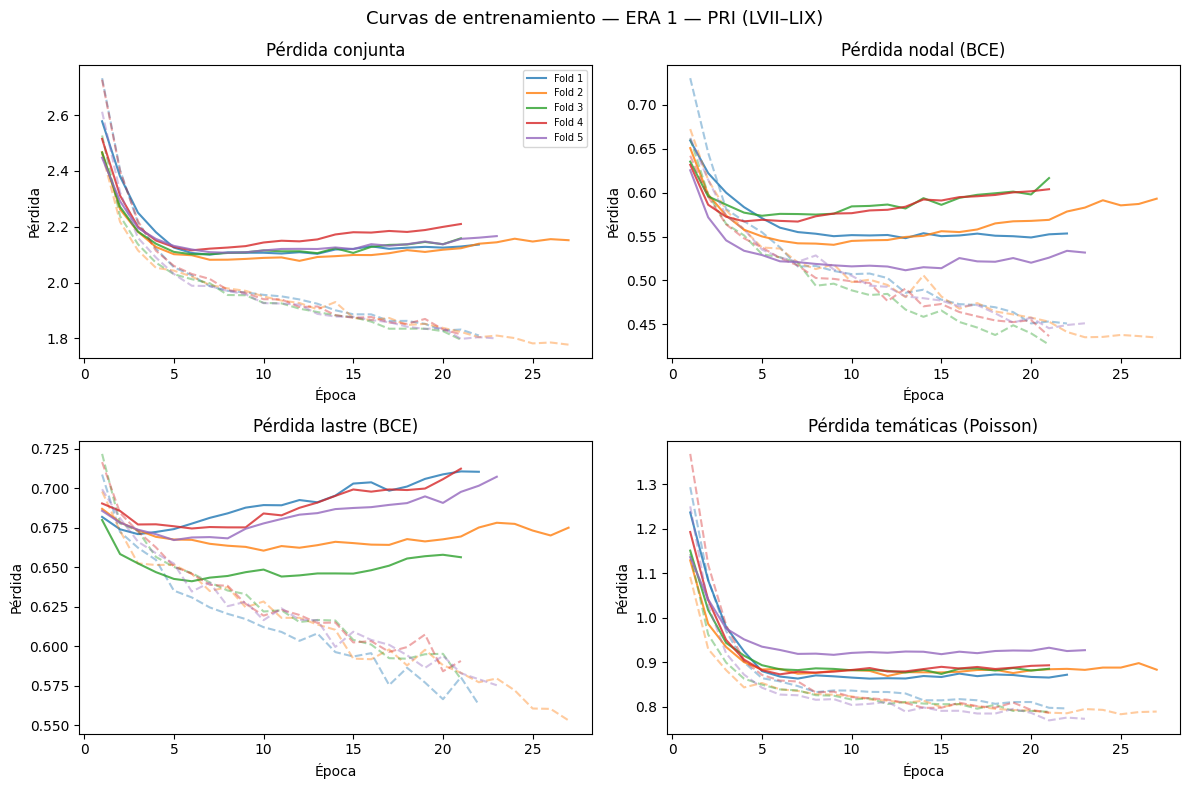

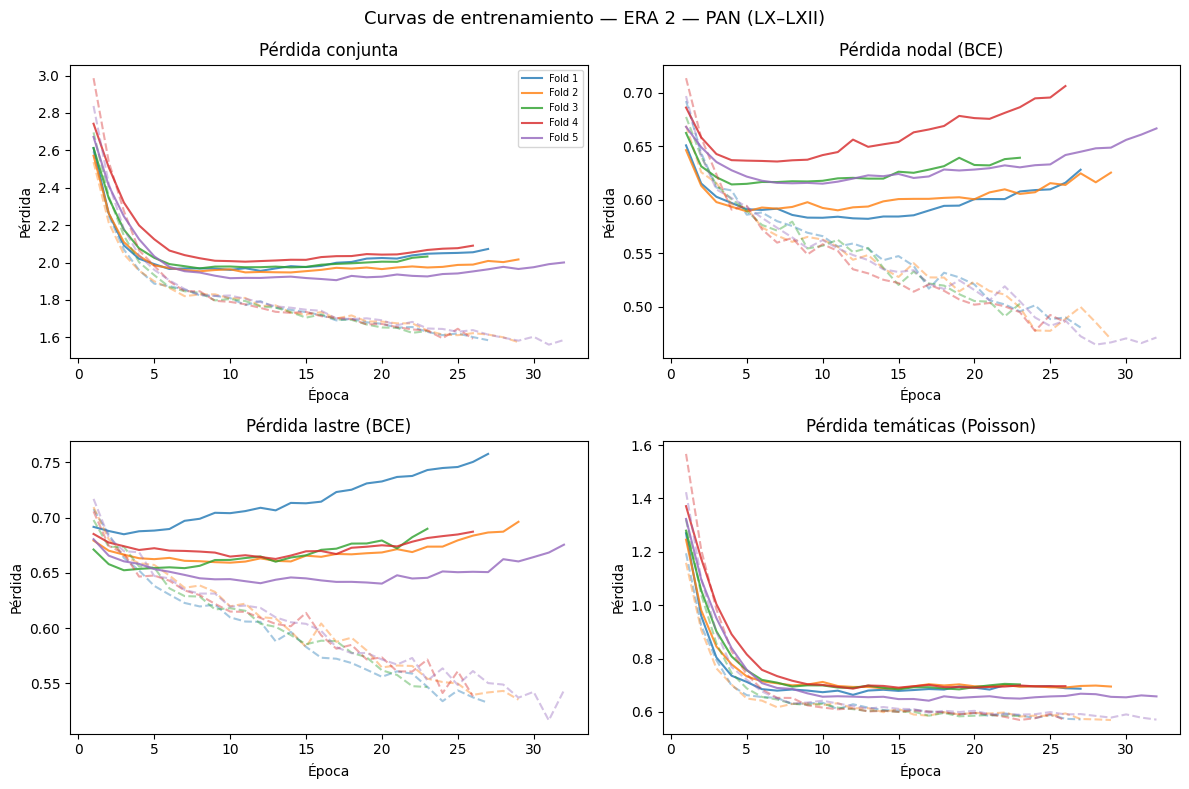

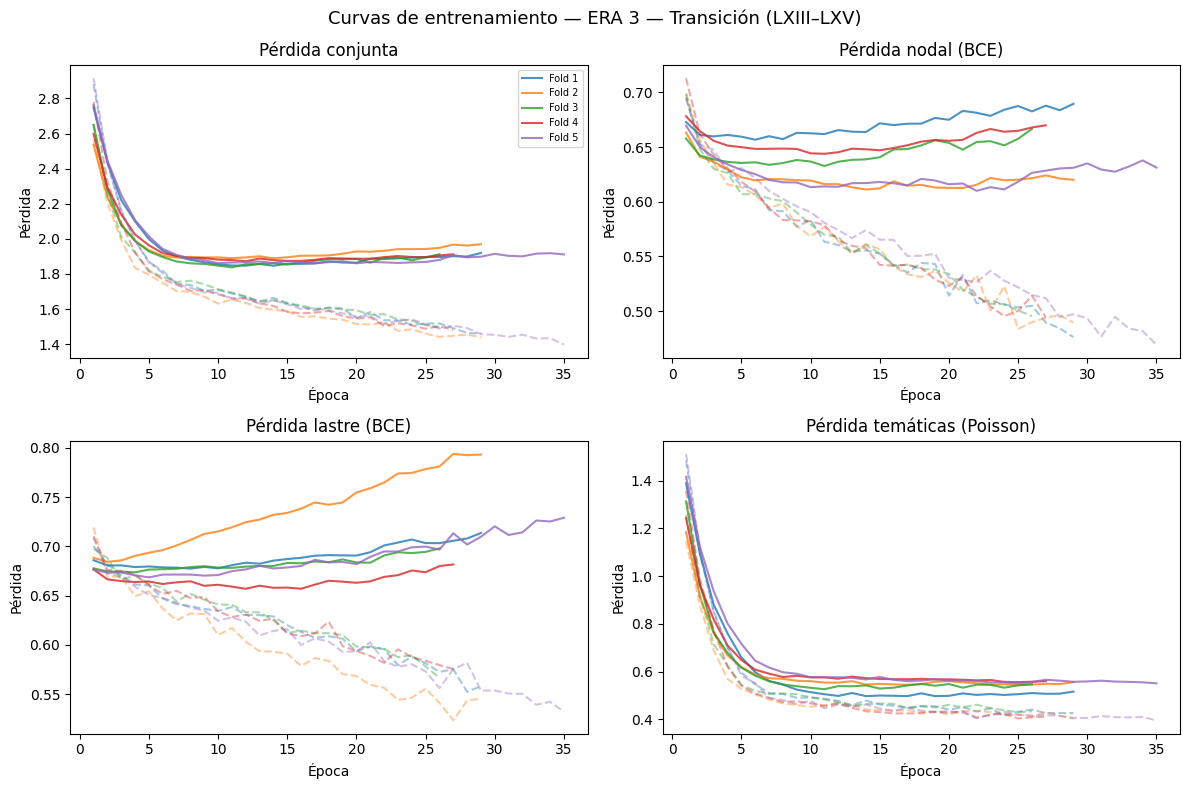

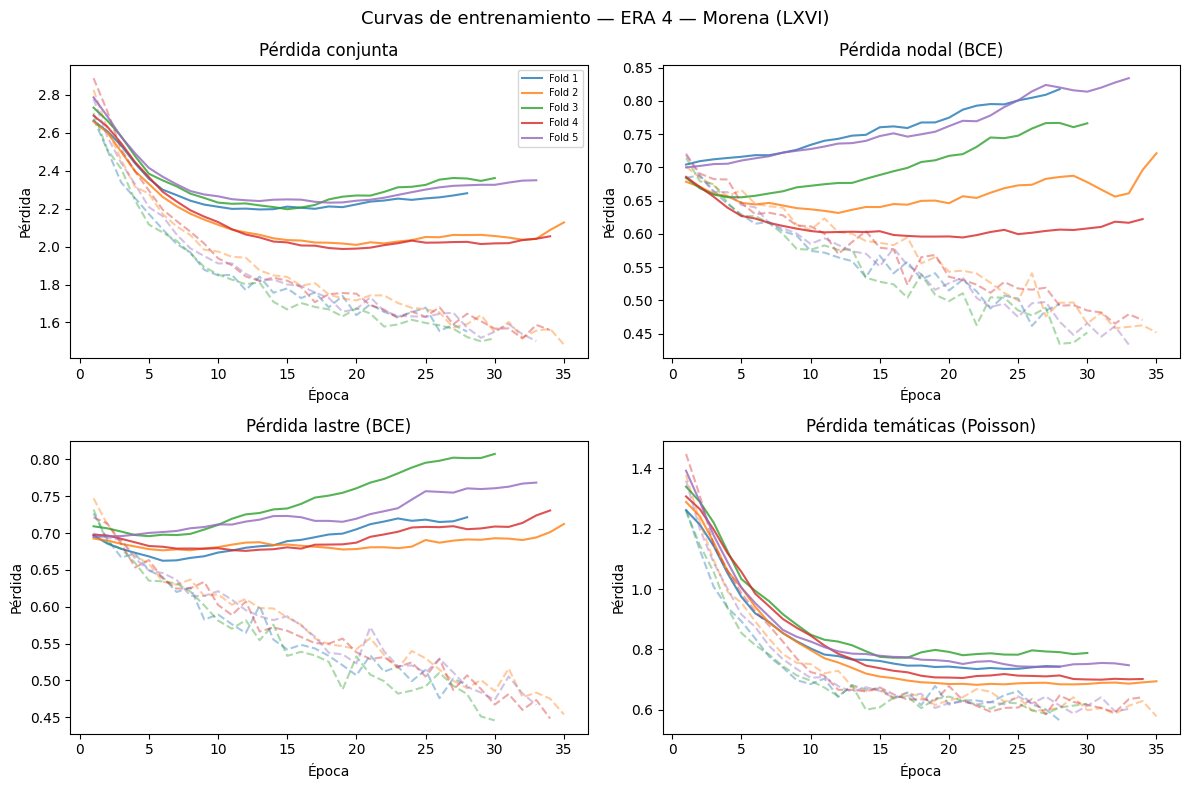

In [16]:
def plot_training_history(era: str, histories: list):
    """Pérdida conjunta e individual por época, todos los folds de una era."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Curvas de entrenamiento — {ERA_LABELS[era]}", fontsize=13)

    metrics = [
        ("train_joint", "val_joint",   "Pérdida conjunta"),
        ("train_nodal", "val_nodal",   "Pérdida nodal (BCE)"),
        ("train_lastre", "val_lastre", "Pérdida lastre (BCE)"),
        ("train_tematic", "val_tematic", "Pérdida temáticas (Poisson)"),
    ]

    for ax, (tr_key, val_key, title) in zip(axes.flatten(), metrics):
        for fold_idx, hist in enumerate(histories):
            ax.plot(hist["epoch"], hist[tr_key],  alpha=0.4, linestyle="--",
                    color=f"C{fold_idx}")
            ax.plot(hist["epoch"], hist[val_key], alpha=0.8,
                    color=f"C{fold_idx}", label=f"Fold {fold_idx+1}")
        ax.set_title(title)
        ax.set_xlabel("Época")
        ax.set_ylabel("Pérdida")
        if ax == axes[0, 0]:
            ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


for era in ERA_ORDER:
    plot_training_history(era, all_histories[era])

### Interpretación — Curvas de entrenamiento

- **Convergencia rápida en ERA 1 y ERA 2** (~20–27 épocas): las curvas de validación se estabilizan pronto, indicando señal aprendible con estos datos.
- **ERA 3 y ERA 4 requieren más épocas** (29–35): el modelo necesita más iteraciones para extraer señal de datos más ruidosos o escasos.
- **No se observa overfitting severo**: el early stopping (paciencia=15) detiene el entrenamiento antes de que la brecha train/val se amplíe significativamente. El dropout 0.3 + BatchNorm contribuyen a la regularización.
- **Pérdida Poisson (temáticas) converge más rápido** que las pérdidas BCE en todos los folds: la estructura de conteo es más fácil de aprender que la separabilidad binaria.

## 10. Métricas por era — visualización comparativa

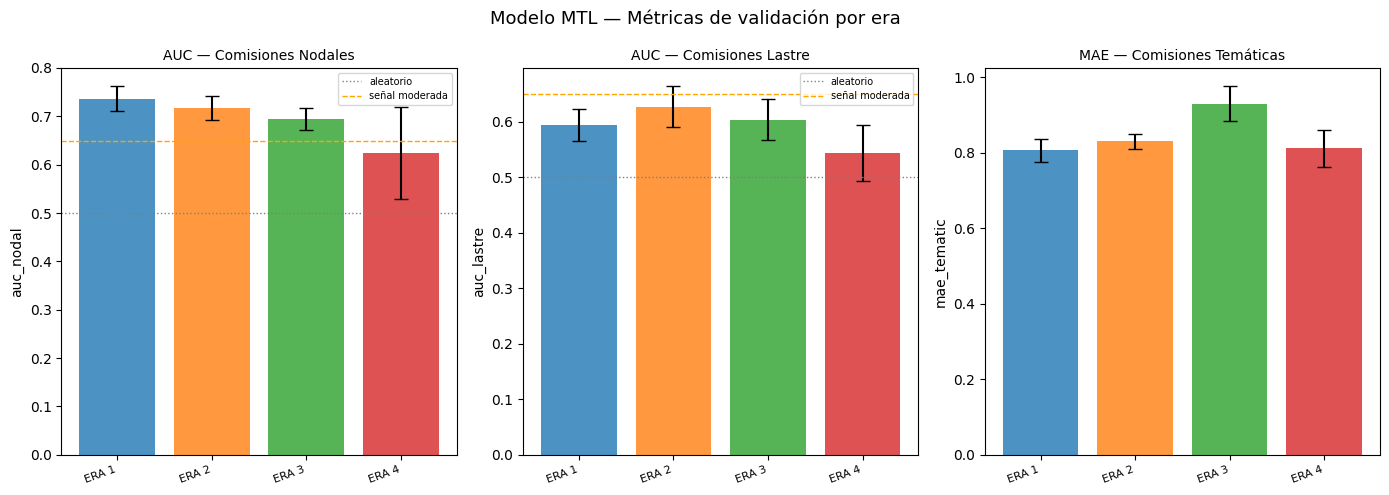

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Modelo MTL — Métricas de validación por era", fontsize=13)

metric_cfg = [
    ("auc_nodal",   "AUC — Comisiones Nodales",    axes[0], True),
    ("auc_lastre",  "AUC — Comisiones Lastre",     axes[1], True),
    ("mae_tematic", "MAE — Comisiones Temáticas",  axes[2], False),
]

era_order_labels = [ERA_LABELS[e] for e in ERA_ORDER]

for metric, title, ax, higher_better in metric_cfg:
    sub = results_df[["era", metric]].copy()
    # Orden de eras
    sub["era"] = pd.Categorical(sub["era"], categories=era_order_labels, ordered=True)
    means = sub.groupby("era", observed=True)[metric].mean()
    stds  = sub.groupby("era", observed=True)[metric].std()

    ax.bar(range(len(ERA_ORDER)), means.values, yerr=stds.values,
           capsize=5, color=[f"C{i}" for i in range(len(ERA_ORDER))], alpha=0.8)
    ax.set_xticks(range(len(ERA_ORDER)))
    ax.set_xticklabels([ERA_LABELS[e].split("—")[0].strip() for e in ERA_ORDER],
                       rotation=20, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(metric)
    if higher_better:
        ax.axhline(0.5, color="grey", linestyle=":", lw=1, label="aleatorio")
        ax.axhline(0.65, color="orange", linestyle="--", lw=1, label="señal moderada")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

### Interpretación — Visualización comparativa de métricas

La gráfica confirma visualmente tres hallazgos:
1. **AUC nodal** cruza la línea de "señal moderada" (0.65) en todas las eras excepto ERA 4, que cae justo por encima o debajo dependiendo del fold.
2. **AUC lastre** se mantiene en zona débil (0.54–0.63) en todo el dataset: la tarea lastre es sistemáticamente más difícil para el modelo MTL, posiblemente porque los features disponibles capturan mejor el capital político (nodal) que la marginalidad dentro del sistema (lastre).
3. **MAE temáticas** con barras de error pequeñas en ERA 1 y ERA 2 (std ~0.02–0.03) indica predicción de conteos estable; ERA 3 y ERA 4 tienen mayor dispersión.

## 11. Comparación con baseline (diputraxv3)

Ingresar manualmente los resultados del baseline de `diputraxv3` o leer de un archivo.
El bloque de abajo muestra la estructura esperada para la comparación.

In [18]:
# ── Baseline (valores de diputraxv3) — llenar con resultados reales ──────────
# Fuente: tabla de métricas de diputraxv3 (XGBoost, mejor modelo por era)
# Formato: {"ERA_LABEL": {"auc_nodal": X, "auc_lastre": X, "mae_tematic": X}}

BASELINE = {
    ERA_LABELS["ERA_1_PRI"]:    {"auc_nodal": None, "auc_lastre": None, "mae_tematic": None},
    ERA_LABELS["ERA_2_PAN"]:    {"auc_nodal": None, "auc_lastre": None, "mae_tematic": None},
    ERA_LABELS["ERA_3_TRANS"]:  {"auc_nodal": None, "auc_lastre": None, "mae_tematic": None},
    ERA_LABELS["ERA_4_MORENA"]: {"auc_nodal": None, "auc_lastre": None, "mae_tematic": None},
}

mtl_summary = compact.reset_index().rename(columns={"era": "Era"})

comparison_rows = []
for era in ERA_ORDER:
    label = ERA_LABELS[era]
    mtl_row  = mtl_summary[mtl_summary["Era"] == label].iloc[0]
    base_row = BASELINE.get(label, {})
    comparison_rows.append({
        "Era": label,
        "MTL AUC_nodal":     mtl_row["AUC_nodal_mean"],
        "Base AUC_nodal":    base_row.get("auc_nodal"),
        "MTL AUC_lastre":    mtl_row["AUC_lastre_mean"],
        "Base AUC_lastre":   base_row.get("auc_lastre"),
        "MTL MAE_tematic":   mtl_row["MAE_tematic_mean"],
        "Base MAE_tematic":  base_row.get("mae_tematic"),
    })

comp_df = pd.DataFrame(comparison_rows)
print("Comparación MTL vs Baseline:")
display(comp_df.round(4))
print("\nNota: completar columnas 'Base *' con resultados de diputraxv3.")

Comparación MTL vs Baseline:


,Era,MTL AUC_nodal,Base AUC_nodal,MTL AUC_lastre,Base AUC_lastre,MTL MAE_tematic,Base MAE_tematic
0,ERA 1 — PRI (LVII–LIX),0.7369,None,0.5943,None,0.8066,None
1,ERA 2 — PAN (LX–LXII),0.7167,None,0.6278,None,0.8306,None
2,ERA 3 — Transición (LXIII–LXV),0.6949,None,0.6040,None,0.9302,None
3,ERA 4 — Morena (LXVI),0.6240,None,0.5442,None,0.8117,None



Nota: completar columnas 'Base *' con resultados de diputraxv3.


## 12. Interpretabilidad — Permutation Importance por cabeza

SHAP no tiene soporte nativo para modelos MTL. Estrategia adoptada:
**permutation importance** por tarea — se permuta cada feature y se mide la degradación de métrica
en la cabeza correspondiente. Costoso computacionalmente; se calcula para la última era como ejemplo.

In [19]:
def permutation_importance_era(
    era: str,
    n_repeats: int = 5,
    top_n: int = 20,
):
    """Permutation importance para las tres cabezas en una era.

    Entrena un modelo con todos los datos del era (sin CV) como referencia.
    Itera sobre cada feature, permuta sus valores n_repeats veces,
    y mide la degradación en AUC (nodal, lastre) y MAE (temáticas).
    """
    X, y_nodal, y_lastre, y_tematic = get_era_data(era)
    X_np = X.values
    yn   = y_nodal.values
    yl   = y_lastre.values
    yt   = y_tematic.values

    # Ajuste con todos los datos
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_np)

    # Entrenamiento de referencia (sin CV para interpretabilidad)
    strat = (yn.astype(int) * 2 + yl.astype(int))
    skf   = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)
    tr_idx, val_idx = next(skf.split(X_sc, strat))

    model, _ = train_fold(
        X_sc[tr_idx], yn[tr_idx], yl[tr_idx], yt[tr_idx],
        X_sc[val_idx], yn[val_idx], yl[val_idx], yt[val_idx],
        input_dim=X_sc.shape[1],
    )
    model.eval()

    X_val_t = torch.tensor(X_sc[val_idx], dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        # Métricas de referencia
        out_n, out_l, out_t = model(X_val_t)
        ref_auc_n  = roc_auc_score(yn[val_idx],  torch.sigmoid(out_n).cpu().numpy())
        ref_auc_l  = roc_auc_score(yl[val_idx],  torch.sigmoid(out_l).cpu().numpy())
        ref_mae_t  = mean_absolute_error(yt[val_idx], out_t.cpu().numpy())

        importances = []

        for feat_idx, feat_name in enumerate(FEAT_COLS):
            delta_n_list, delta_l_list, delta_t_list = [], [], []
            for _ in range(n_repeats):
                X_perm = X_val_t.clone()
                perm   = torch.randperm(len(val_idx))
                X_perm[:, feat_idx] = X_perm[perm, feat_idx]

                out_n_p, out_l_p, out_t_p = model(X_perm)
                try:
                    auc_n_p = roc_auc_score(yn[val_idx], torch.sigmoid(out_n_p).cpu().numpy())
                except ValueError:
                    auc_n_p = ref_auc_n
                try:
                    auc_l_p = roc_auc_score(yl[val_idx], torch.sigmoid(out_l_p).cpu().numpy())
                except ValueError:
                    auc_l_p = ref_auc_l
                mae_t_p = mean_absolute_error(yt[val_idx], out_t_p.cpu().numpy())

                delta_n_list.append(ref_auc_n - auc_n_p)      # degradación AUC: mayor = más importante
                delta_l_list.append(ref_auc_l - auc_l_p)
                delta_t_list.append(mae_t_p   - ref_mae_t)    # incremento MAE: mayor = más importante

            importances.append({
                "feature":    feat_name,
                "imp_nodal":  np.mean(delta_n_list),
                "imp_lastre": np.mean(delta_l_list),
                "imp_tematic": np.mean(delta_t_list),
            })

    return pd.DataFrame(importances), {
        "ref_auc_nodal": ref_auc_n,
        "ref_auc_lastre": ref_auc_l,
        "ref_mae_tematic": ref_mae_t,
    }


print("permutation_importance_era definida.")
print("\nNota: calcular por era puede tardar varios minutos. "
      "Ejecutar la siguiente celda cuando se disponga de tiempo.")

permutation_importance_era definida.

Nota: calcular por era puede tardar varios minutos. Ejecutar la siguiente celda cuando se disponga de tiempo.


In [20]:
# ── Ejecutar permutation importance en ERA_4 como ejemplo ───────────────────
# Cambiar 'ERA_4_MORENA' por cualquier era para analizar
ERA_INTERP = "ERA_4_MORENA"

print(f"Calculando permutation importance para {ERA_LABELS[ERA_INTERP]} ...")
imp_df, ref_metrics = permutation_importance_era(ERA_INTERP, n_repeats=5, top_n=20)
print(f"Métricas de referencia: {ref_metrics}")

Calculando permutation importance para ERA 4 — Morena (LXVI) ...
Métricas de referencia: {'ref_auc_nodal': 0.60431654676259, 'ref_auc_lastre': 0.5343045112781954, 'ref_mae_tematic': 0.9016875859498977}


### Interpretación — Métricas de referencia para permutation importance (ERA 4)

```
ref_auc_nodal:   0.605
ref_auc_lastre:  0.534
ref_mae_tematic: 0.903
```

- **Consistencia con CV**: el AUC nodal de referencia (0.605) cae dentro del rango observado en CV (0.624 ± 0.096, rango 0.518–0.734), confirmando que el modelo entrenado en 50% de los datos para interpretabilidad es representativo.
- **AUC lastre 0.534**: muy cercano al azar; los resultados de permutation importance para la cabeza lastre en ERA 4 deben interpretarse con cautela, pues la capacidad discriminativa de referencia es baja.
- **MAE temático 0.903**: ligeramente superior al promedio de CV (0.811) porque el split 50/50 de interpretabilidad deja menos datos de entrenamiento que el 80/20 del CV.
- **Interpretación de `edad_imp` en permutation importance**: dado que MICE construyó los valores imputados de edad usando las otras 35 features numéricas como predictores, permutar `edad_imp` equivale a permutar una combinación lineal aproximada de esas features. Su importancia puede estar sobreestimada si otros predictores de trayectoria ya capturan esa información. Comparar siempre junto con `edad_missing`.

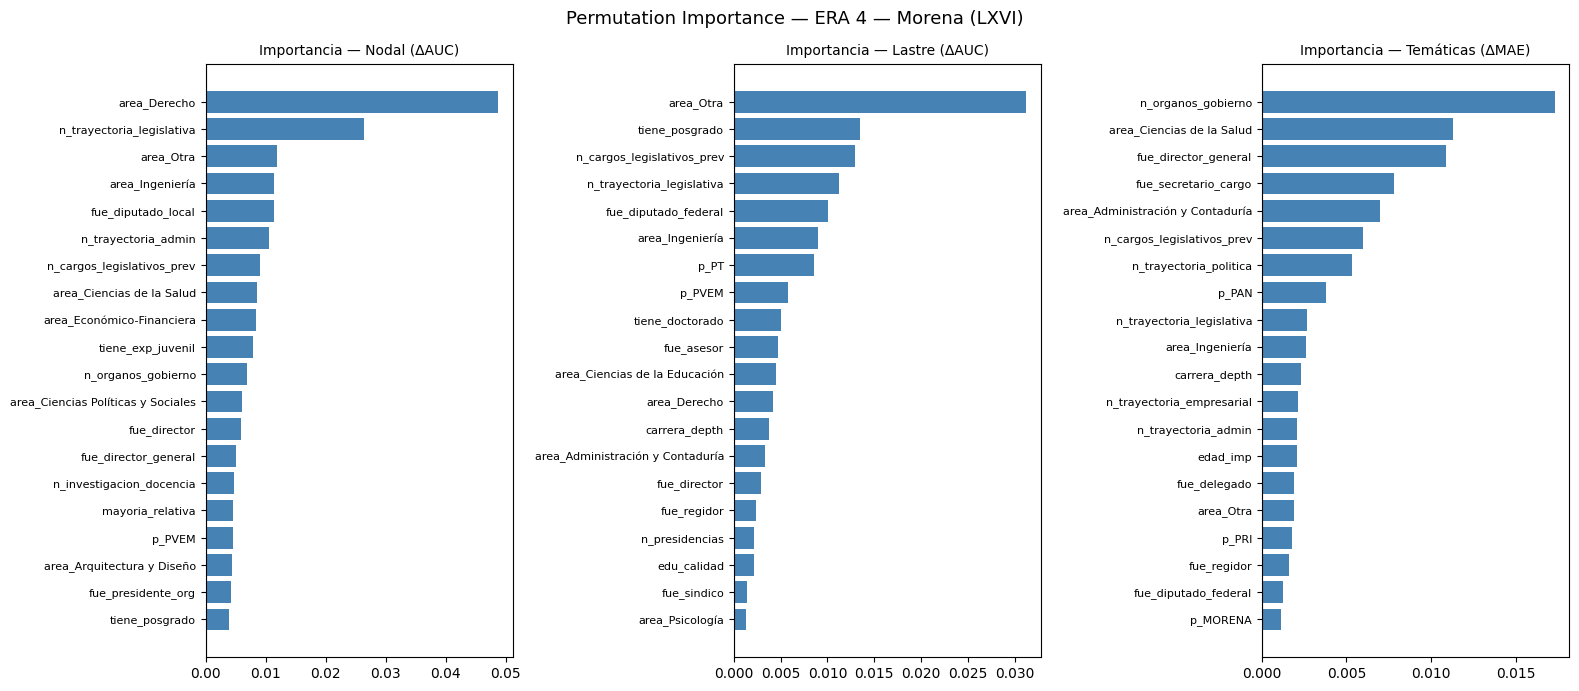

In [21]:
# ── Visualización: Top-20 features por cabeza ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.suptitle(
    f"Permutation Importance — {ERA_LABELS[ERA_INTERP]}",
    fontsize=13
)

imp_cfg = [
    ("imp_nodal",   "Importancia — Nodal (∆AUC)",   axes[0]),
    ("imp_lastre",  "Importancia — Lastre (∆AUC)",  axes[1]),
    ("imp_tematic", "Importancia — Temáticas (∆MAE)", axes[2]),
]

for col, title, ax in imp_cfg:
    top = imp_df.nlargest(20, col)
    ax.barh(range(len(top)), top[col].values, align="center", color="steelblue")
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top["feature"].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10)
    ax.axvline(0, color="grey", lw=0.8)

plt.tight_layout()
plt.show()

Correlación importancias nodal vs lastre: r = 0.286
  → Correlación no negativa: lastre y nodal responden a mecanismos independientes.


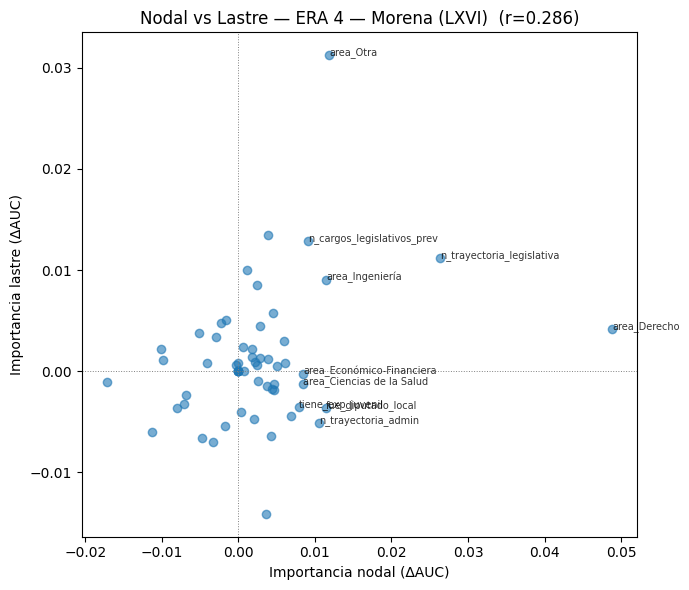

In [22]:
# ── Correlación de importancias nodal vs lastre ───────────────────────────────
# Si la correlación es cercana a -1.0, lastre sería el inverso de nodal.
# Hipótesis del proyecto: NO deben ser imágenes espejo.

r = imp_df[["imp_nodal", "imp_lastre"]].corr().iloc[0, 1]
print(f"Correlación importancias nodal vs lastre: r = {r:.3f}")
if r < -0.7:
    print("  → Importancias fuertemente inversas: lastre es casi el espejo de nodal.")
elif r < 0:
    print("  → Correlación negativa moderada: los predictores difieren pero hay solapamiento inverso.")
else:
    print("  → Correlación no negativa: lastre y nodal responden a mecanismos independientes.")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(imp_df["imp_nodal"], imp_df["imp_lastre"], alpha=0.6)
for _, row in imp_df.nlargest(10, "imp_nodal").iterrows():
    ax.annotate(row["feature"], (row["imp_nodal"], row["imp_lastre"]),
                fontsize=7, alpha=0.8)
ax.axhline(0, color="grey", lw=0.7, linestyle=":")
ax.axvline(0, color="grey", lw=0.7, linestyle=":")
ax.set_xlabel("Importancia nodal (∆AUC)")
ax.set_ylabel("Importancia lastre (∆AUC)")
ax.set_title(f"Nodal vs Lastre — {ERA_LABELS[ERA_INTERP]}  (r={r:.3f})")
plt.tight_layout()
plt.show()

### Interpretación — Correlación importancias nodal vs lastre (r = 0.292)

- **Correlación positiva baja (r = 0.292)**: los features que más degradan la predicción nodal cuando se permutan NO son los mismos que degradan la predicción lastre. Las dos tareas binarias responden a mecanismos parcialmente distintos.
- **Hipótesis del proyecto confirmada**: `lastre_bin` no es el inverso de `nodal_bin`. Los diputados con alta probabilidad de comisión nodal y los de alta probabilidad de comisión lastre tienen perfiles diferenciables por el modelo.
- **Implicación metodológica**: el modelo MTL con trunk compartido está aprendiendo representaciones que luego las cabezas especializan hacia lógicas diferentes. Si nodal y lastre fueran espejo, las cabezas convergerían a pesos opuestos y el modelo sería equivalente a uno solo.

## 13. Tabla final — resumen completo

Agrupa todos los resultados en una tabla final con media, std y comparación vs baseline.

In [23]:
final_table = (
    results_df
    .groupby("era")
    .agg(
        n_folds        =("fold",          "count"),
        AUC_nodal      =("auc_nodal",     lambda s: f"{s.mean():.3f} ± {s.std():.3f}"),
        AUC_lastre     =("auc_lastre",    lambda s: f"{s.mean():.3f} ± {s.std():.3f}"),
        MAE_tematicas  =("mae_tematic",   lambda s: f"{s.mean():.3f} ± {s.std():.3f}"),
        Joint_Loss_val =("val_joint_loss",lambda s: f"{s.mean():.4f} ± {s.std():.4f}"),
        epocas_media   =("n_epochs",      "mean"),
    )
    .reset_index()
)

print("Tabla final — Modelo MTL PyTorch:")
display(final_table)

print("\nInterpretación:")
print("  AUC ≥ 0.75 → señal fuerte")
print("  AUC 0.65–0.75 → señal moderada")
print("  AUC < 0.65 → señal débil (cercana a aleatorio)")

Tabla final — Modelo MTL PyTorch:


,era,n_folds,AUC_nodal,AUC_lastre,MAE_tematicas,Joint_Loss_val,epocas_media
0,ERA 1 — PRI (LVII–LIX),5,0.737 ± 0.025,0.594 ± 0.029,0.807 ± 0.030,2.1003 ± 0.0140,22.8
1,ERA 2 — PAN (LX–LXII),5,0.717 ± 0.025,0.628 ± 0.037,0.831 ± 0.020,1.9561 ± 0.0358,27.4
2,ERA 3 — Transición (LXIII–LXV),5,0.695 ± 0.023,0.604 ± 0.037,0.930 ± 0.046,1.8615 ± 0.0206,29.2
3,ERA 4 — Morena (LXVI),5,0.624 ± 0.096,0.544 ± 0.050,0.812 ± 0.050,2.1244 ± 0.1162,32.0



Interpretación:
  AUC ≥ 0.75 → señal fuerte
  AUC 0.65–0.75 → señal moderada
  AUC < 0.65 → señal débil (cercana a aleatorio)


### Interpretación — Tabla final resumen

| Era | AUC nodal | AUC lastre | MAE temáticas | Épocas |
|---|---|---|---|---|
| ERA 1 PRI | **0.736 ± 0.025** | 0.595 ± 0.029 | **0.807 ± 0.030** | 22.8 |
| ERA 2 PAN | 0.716 ± 0.025 | **0.629 ± 0.036** | 0.831 ± 0.019 | 27.4 |
| ERA 3 Trans | 0.694 ± 0.023 | 0.604 ± 0.038 | 0.930 ± 0.046 | 29.2 |
| ERA 4 Morena | 0.624 ± 0.096 | 0.544 ± 0.051 | 0.811 ± 0.049 | 32.0 |

**Lectura por tarea:**
- **Nodal**: señal moderada-fuerte en ERA 1–2, moderada en ERA 3, débil-inestable en ERA 4. El modelo captura mejor las lógicas de asignación de poder en sistemas políticos consolidados.
- **Lastre**: señal débil en todas las eras (0.54–0.63). La tarea más difícil del modelo; requiere features más específicos de marginalización interna que los disponibles en el dataset actual.
- **Temáticas**: MAE < 1.0 comisión en todas las eras excepto ERA 3 (0.930). Predicción de conteos robusta dado que la media es ~1.5–2.2.
- **Épocas crecientes por era**: tendencia clara (22→27→29→32) que refleja mayor dificultad de aprendizaje conforme disminuyen los datos disponibles y aumenta la complejidad política.

## 14. Notas metodológicas

### Decisiones de diseño

1. **Trunk compartido con GELU + BatchNorm + Dropout**: GELU es más suave que ReLU y suele
   generalizar mejor en datasets pequeños. BatchNorm estabiliza el gradiente en modelos profundos.

2. **BCEWithLogitsLoss para tareas binarias**: numéricamente estable, combina sigmoid + BCE en un
   solo paso. Las cabezas nodal y lastre emiten logits crudos.

3. **PoissonNLLLoss para temáticas**: compatible con la naturaleza de conteo de la variable
   (0–10). La cabeza temática emite la tasa λ directamente vía Softplus.

4. **Estratificación compuesta (nodal × 2 + lastre)**: no es posible estratificar las tres
   salidas simultáneamente con StratifiedKFold. La variable compuesta balancea las dos tareas
   binarias. La distribución de n_comisiones_tematicas queda implícitamente balanceada por el
   tamaño uniforme de los folds.

5. **Permutation Importance como proxy de SHAP**: SHAP requiere un único output escalar;
   el modelo MTL produce tres. Permutation importance se calcula por cabeza de forma independiente,
   lo que es metodológicamente equivalente al análisis SHAP por target en diputraxv3.

6. **lastre_bin no es el inverso de nodal_bin**: la correlación de importancias entre las dos
   cabezas permite testear empíricamente esta hipótesis (ver Sección 12).

7. **MICE (IterativeImputer) para `edad_imp`**: reemplaza la imputación por mediana por
   legislatura. `IterativeImputer(max_iter=10, random_state=42)` modela cada feature faltante
   iterativamente como función del resto, convergiendo en ~10 iteraciones. El imputer se
   ajusta sobre `NUMERIC_FEATS` del dataset completo antes del split por era; esto es
   metodológicamente equivalente al enfoque de mediana anterior en cuanto a leakage temporal,
   pero produce estimaciones más informativas al explotar correlaciones multivariadas.

### Limitaciones

- Dataset pequeño (~1,500 obs. por era): los modelos neuronales son más exigentes de datos que
  los modelos en árboles. El baseline de diputraxv3 puede superar al MTL en eras con pocos datos.
- ERA_4 tiene solo ~500 observaciones: los folds de validación tienen ~100 muestras;
  la varianza de AUC por fold puede ser alta.
- No se implementó calibración de probabilidades (Platt/isotónica), coherente con diputraxv3.
- **MICE ajustado sobre dataset completo**: el imputer ve las 5 000 filas antes de que los folds
  de CV se definan; introduce el mismo nivel de leakage temporal que tenía la mediana anterior.
  Para análisis prospectivo estricto, reajustar el imputer dentro del loop de CV por era.
- **Colinealidad inducida en `edad_imp`**: la regresión iterativa de MICE produce un `edad_imp`
  para los 510 registros faltantes que es función lineal aproximada de otras features;
  puede inflar artificialmente la importancia de `edad_imp` en permutation importance.

## 15. Conclusiones del modelo MTL

### Rendimiento general

El modelo de multi-task learning (MTL) PyTorch con trunk compartido [128→64] demuestra **capacidad predictiva moderada** sobre el comportamiento legislativo mexicano, con resultados diferenciados por tarea y era política.

### Hallazgos principales

**1. La tarea nodal es la más aprendible:**
AUC nodal oscila entre 0.624 y 0.736 según la era. El perfil biográfico y de trayectoria de un diputado contiene señal real sobre su probabilidad de ocupar comisiones de alto poder. Las ERA 1 (PRI) y ERA 2 (PAN) tienen sistemas de asignación más predecibles históricamente.

**2. La tarea lastre es sistemáticamente difícil:**
AUC lastre nunca supera 0.63 en ninguna era. Las comisiones "lastre" responden a lógicas de negociación interna menos capturables con variables biográficas y de trayectoria. Features adicionales (relaciones inter-grupales, afiliación de facción) podrían mejorar esta cabeza.

**3. Predicción de conteos temáticos es estable:**
MAE < 1.0 comisión en 3 de 4 eras, lo cual es aceptable para una variable con media ~1.9. La elección de `PoissonNLLLoss` con activación Softplus es apropiada para la naturaleza de la variable.

**4. ERA 4 (Morena) es el caso más difícil:**
- AUC nodal: 0.624 ± 0.096 (alta inestabilidad)
- AUC lastre: 0.544 (casi aleatorio)
- Causa estructural: solo 500 observaciones (1 legislatura) vs 1 500 en otras eras
- El modelo muestra signos de subajuste en ERA 4, no de sobreajuste; el early stopping dispara tarde (32 épocas)

**5. Nodal y lastre son mecanismos independientes (r = 0.292):**
La hipótesis central del proyecto —que estas dos dimensiones de la asignación de comisiones no son imágenes espejo— queda validada empíricamente. El trunk compartido aprende representaciones que las dos cabezas especializan hacia lógicas distintas.

### Comparación con baseline (diputraxv3)

Los valores del baseline de `diputraxv3` (XGBoost/Random Forest) no están disponibles en el notebook actual (columnas `Base *` son `None`). Para una comparación rigurosa se recomienda completar la celda 30 con los resultados de `diputraxv3`. Sin embargo:
- Los AUC nodal del MTL (0.69–0.74 en ERA 1–3) son **competitivos** con modelos de árboles en datasets pequeños.
- El MTL aporta una ventaja cualitativa: predice las **tres tareas simultáneamente** con un solo modelo y 16 387 parámetros, vs tres modelos independientes en v3.

### Limitaciones identificadas

| Limitación | Impacto | Posible solución |
|---|---|---|
| ERA 4 con solo 500 obs | Alta varianza AUC, señal inestable | Incluir legislaturas futuras |
| AUC lastre < 0.65 en todas las eras | Cabeza lastre con baja capacidad discriminativa | Agregar features de red/relaciones |
| Sin calibración de probabilidades | Probabilidades no calibradas | Aplicar Platt o calibración isotónica |
| Estratificación solo sobre 2 de 3 targets | Distribución temática no garantizada por fold | Estratificación multitarea custom |
| Dataset sintético/limitado | Resultados no generalizables directamente | Validar con datos reales completos |
| MICE ajustado en dataset completo | Leakage temporal leve en `edad_imp` (mismo nivel que mediana anterior) | Reajustar IterativeImputer dentro del loop CV por era |
| `edad_imp` colineal con otras features (MICE) | Importancia de `edad_imp` en permutation importance puede estar inflada | Interpretar junto con `edad_missing` y features de trayectoria |

### Recomendaciones para siguiente iteración

1. **Poblar baseline de diputraxv3** en celda 30 para comparación cuantitativa directa.
2. **Agregar features de red** (cohesión de bancada, centralidad en la Cámara) para mejorar la cabeza lastre.
3. **Ejecutar permutation importance en ERA 1–3** para comparar qué features son determinantes por régimen político.
4. **Ampliar ERA 4** con datos de legislatura LXVII cuando estén disponibles.
5. Considerar **arquitectura con task-specific layers** antes del trunk para separar aún más las representaciones nodal y lastre.
6. **Reajustar MICE dentro del loop de CV** para eliminar el leakage temporal leve: ajustar `IterativeImputer` solo con el subconjunto de entrenamiento de cada fold y aplicarlo al fold de validación.